# Switch-dependence diagnostics — empirical motivation of the spatial Gaussian field

Diagnostic of §"Empirical spatial structure of the exit indicators" of [main.tex](Spatialisation-Rain-Occurrence-Generator-article/main.tex), on the ECAD Spain+Portugal record: the conditional Pearson correlation of the exit indicators $b_{n,j} = \mathbb{1}\{r_{n+1,j} \neq r_{n,j}\}$ of a station pair $(j,j')$, over the days where the pair carries a fixed state pair $(x,x')$, $x = (r,d)$ being a spell type **and** an exact duration — eq. (tmp_phi_estimator),
$$\widehat{\psi}_{jj'}(x,x') = \frac{N_{jj'}(x,x')\,e_{jj'}-e_j\,e_{j'}}{\sqrt{e_j\big(N_{jj'}(x,x')-e_j\big)\;e_{j'}\big(N_{jj'}(x,x')-e_{j'}\big)}},$$
with $N_{jj'}(x,x')$ the number of such days, $e_j, e_{j'}$ the exit counts and $e_{jj'}$ the joint exit count. Conditioning on the exact durations freezes the two exit probabilities, so the independence baseline is exactly $0$ and no fitted quantity enters: **one dot per (station pair, state pair)**, model-free, keeping $N \geq 10$ and non-degenerate margins.

By eq. (phi_from_rho), $\psi_{jj'}(x,x')$ has the sign of the latent correlation $\rho^{(r,r')}_{jj'}$ and vanishes with it, so the LMC requirements are read straight off the clouds: $\psi > 0$ decaying with distance for concordant states (one field per state), $\psi < 0$ for discordant ones (a common field with opposite signs), and a dry/wet asymmetry ($\lambda^{(0)} \neq \lambda^{(1)}$).

Three figures, implemented in [switch_phi_duration_diagnostic.py](switch_phi_duration_diagnostic.py), all on a season $\times$ state-pair-class grid against inter-station distance: **(1)** the observed dots with their $N$-weighted mean and 10/90% – 20/80% quantile curves, Figure 1 of the article; **(2)** observed and simulated dots in two sub-rows per season, each with its median curve (red / blue); **(3)** the two estimations on the same axes without dots — median and the 10/90, 20/80, 30/70, 40/60 quantile pairs.

## Setup

Same data pipeline as [spatial_lin_mod_coregion_fit_spain_portugal.ipynb](spatial_lin_mod_coregion_fit_spain_portugal.ipynb): single-site outputs (spells, metadata, fitted dry/wet distribution parameters), per-season PT/ES station subsets, raw daily rainfall, and the per-year observed histories (R, D, S) with the ambiguous-spell NaN masking of the likelihood. The raw occurrence frames `Rbin` are kept as well: they carry the dates and the missing-data pattern that the simulated replicates of the last section reuse.

In [1]:
import sys, pathlib
_HERE = pathlib.Path.cwd().resolve()
_REPO_ROOT = next(
    (p for p in (_HERE, *_HERE.parents) if (p / "article_code").is_dir()),
    None,
)
if _REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root containing 'article_code/' from {_HERE}")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import json
import numpy as np
import pandas as pd

from article_code.util_files import config
from spatial_bmcd.spatial_model import (
    prepare_station_fit_table,
    build_dict_model_params,
    load_all_station_rr,
    filter_stations_by_nan_fraction,
    build_joint_df_occurrence_from_raw_data,
    history_from_Rbin_drop_ambiguous_spell_after_nan,
    split_history_by_year,
)
from spatial_bmcd.switch_phi_duration_diagnostic import (
    switch_phi_duration_cells,
    plot_phi_per_cell_season_grid,
    season_trend_summary,
    simulate_phi_cells,
    plot_phi_obs_vs_sim_paired_rows,
    plot_phi_quantile_fan_season_grid,
    obs_vs_sim_trend_summary,
    figure_targets,
)

# Single-site outputs of the data-preparation notebook.
base_filename = (
    f"ecad_data_south_europe_filtered_after_{config.START_YEAR}"
    f"_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json"
)
with open(config.EXPORTS_JSON_DIR / base_filename) as fh:
    spells = json.load(fh)
stations_metadata = pd.read_csv(config.STATION_METADATA_CSV)
stations_used = stations_metadata[stations_metadata["city"].isin(spells.keys())]

fit_folder = (
    config.RESULTS_FIT_DIR
    / f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}"
)
df_fit_dry = pd.read_csv(fit_folder / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv")
df_fit_wet = pd.read_csv(fit_folder / "wet_spell_fit_mixt_geomresult_fit_parameters.csv")
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s: s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s: s.split()[-1])

COUNTRIES = ["PT", "ES"]
SEASONS = list(config.SEASONS)
YEAR_MIN, YEAR_MAX = 1980, 2020

def build_params_by_season(stations_used):
    """Per-season {city: model parameters} of the PT/ES subset of `stations_used`."""
    out = {}
    for season in SEASONS:
        df_fit_dry_sub, df_fit_wet_sub = prepare_station_fit_table(
            df_fit_dry, df_fit_wet, stations_used, countries=COUNTRIES, season=season,
        )
        out[season] = build_dict_model_params(
            df_fit_dry_sub, df_fit_wet_sub, spells, season=season, show_progress=False,
        )
    return out

# Station set, settled in two passes: how incomplete a station is can only be
# read from the raw record, so a provisional set says which files to load,
# filter_stations_by_nan_fraction drops the stations missing more than
# MAX_NAN_FRACTION_STATION of the window (see spatial_bmcd/config_spatial.py),
# and the second pass is the definitive set. Only the load touches the disk.
per_season_params = build_params_by_season(stations_used)
stations_union = sorted(set().union(*(p.keys() for p in per_season_params.values())))
# Raw daily RR, loaded once for the union of stations across seasons.
dfs_by_city = load_all_station_rr(config.ECAD_RAW_DIR, stations_to_get=stations_union, verbose=False)

stations_used = filter_stations_by_nan_fraction(stations_used, dfs_by_city)
per_season_params = build_params_by_season(stations_used)
stations_union = sorted(set().union(*(p.keys() for p in per_season_params.values())))
dfs_by_city = {c: df for c, df in dfs_by_city.items() if c in stations_union}

# Per-year observed histories (R, D, S) per season, same masking as the MLE,
# plus the raw occurrence frame Rbin (dates + missing-data pattern).
histories_by_season, params_by_station_by_season, Rbin_by_season = {}, {}, {}
for season in SEASONS:
    params = per_season_params[season]
    stations = sorted(c for c in params if c in dfs_by_city)
    Rbin = build_joint_df_occurrence_from_raw_data(
        dfs_by_city, season=season, station_names=stations,
        wet_day_threshold=float(config.WET_DAY_THRESHOLD),
    )
    Rbin = Rbin.loc[(Rbin.index.year >= YEAR_MIN) & (Rbin.index.year <= YEAR_MAX)]
    history = history_from_Rbin_drop_ambiguous_spell_after_nan(Rbin)
    histories_by_season[season] = split_history_by_year(history)
    params_by_station_by_season[season] = {c: params[c] for c in history["station_names"]}
    Rbin_by_season[season] = Rbin[history["station_names"]]

print("stations per season: " + ", ".join(
    f"{s}={len(params_by_station_by_season[s])}" for s in SEASONS))

stations per season: spring=35, summer=35, autumn=35, winter=35


## The estimates $\widehat{\psi}_{jj'}(x,x')$, all seasons

`switch_phi_duration_cells` returns one row per (station pair, state pair): the two spell types $(r,r')$, the two exact durations $(d,d')$, the number of days $N_{jj'}(x,x')$ they were jointly observed in that state pair, the exit counts, and $\widehat{\psi}$ (`phi`, `NaN` when $N < 10$ or a margin is degenerate — those rows are kept only for the day accounting). Cached to one CSV per season in `experiment_outputs/` — delete a CSV to force recomputation.

In [2]:
OUTPUT_DIR = _REPO_ROOT / "spatial_bmcd" / "experiment_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MIN_DAYS = 10  # admissibility threshold N_{jj'}(x, x') >= 10 of the article

cells_by_season = {}
for season in SEASONS:
    csv_path = OUTPUT_DIR / f"switch_phi_duration_cells_{season}.csv"
    if csv_path.exists():
        cells_by_season[season] = pd.read_csv(csv_path)
        print(f"[{season:>6}] loaded {len(cells_by_season[season])} rows from {csv_path.name}")
        continue
    cells_by_season[season] = switch_phi_duration_cells(
        histories_by_season[season], params_by_station_by_season[season],
        min_days_per_cell=MIN_DAYS,
    )
    cells_by_season[season].to_csv(csv_path, index=False)
    print(f"[{season:>6}] computed {len(cells_by_season[season])} rows -> {csv_path.name}")

# The four rows of the figures must rest on the same stations to be comparable.
station_sets = {s: set(params_by_station_by_season[s]) for s in SEASONS}
common = set.intersection(*station_sets.values())
assert all(v == common for v in station_sets.values()), "seasonal station sets differ"
print(f"\n{len(common)} stations common to the four seasons, "
      f"{len(common) * (len(common) - 1) // 2} station pairs")

rows = []
for season, cells in cells_by_season.items():
    adm = cells[np.isfinite(cells["phi"])]
    for cls, sub in adm.groupby("state_class"):
        all_cls = cells[cells["state_class"] == cls]
        rows.append({
            "season": season, "class": cls,
            "dots (admissible)": len(sub),
            "median N": sub["n_days"].median(), "max N": sub["n_days"].max(),
            "days used / class days": sub["n_days"].sum() / all_cls["n_days"].sum(),
        })
print("\nadmissible estimates (N >= 10, non-degenerate margins):")
print(pd.DataFrame(rows).set_index(["season", "class"]).round(3).to_string())

[spring] loaded 200765 rows from switch_phi_duration_cells_spring.csv


[summer] loaded 286640 rows from switch_phi_duration_cells_summer.csv
[autumn] loaded 193686 rows from switch_phi_duration_cells_autumn.csv


[winter] loaded 214685 rows from switch_phi_duration_cells_winter.csv

35 stations common to the four seasons, 595 station pairs



admissible estimates (N >= 10, non-degenerate margins):
                dots (admissible)  median N  max N  days used / class days
season class                                                              
spring dry-dry               5498      17.0    174                   0.343
       dry-wet               4793      15.0     93                   0.383
       wet-wet               2777      18.0    169                   0.613
summer dry-dry               2439      17.0    138                   0.119
       dry-wet               1418      13.0     63                   0.182
       wet-wet                687      17.0    135                   0.557
autumn dry-dry               5320      17.0    183                   0.351
       dry-wet               4534      14.0     81                   0.381
       wet-wet               2581      19.0    199                   0.610
winter dry-dry               4539      17.0    187                   0.304
       dry-wet               3874      14.0

## Figure 1 of the article — $\widehat{\psi}_{jj'}(x,x')$ against distance

One dot per admissible (station pair, state pair) estimate, against the inter-station distance $\|\mathbf{s}_j - \mathbf{s}_{j'}\|$ in the normalised coordinates of §"Exponential correlation function". Columns: state-pair classes (both dry, both wet, discordant); rows: the four seasons, sharing the same stations, the same $y$-axis and a single $\sqrt{N}$ size/opacity normalisation, so the panels are directly comparable. Over eight equal-count distance bins, the red curves give the $N$-weighted mean (solid, with markers) and the $N$-weighted 10/90% (dotted) and 20/80% (dashed) quantiles of the dots in the bin; the dotted grey line is the independence baseline $\psi = 0$.

Written to `figures/diag_switch_phi_duration_per_cell_seasons.pdf` of the article directory (plus a `.png` copy and one in `figures/spatial/`).

season   class  n_dots  max_N  phi_bar_near  phi_bar_far  phi_bar_min  phi_bar_max  monotone_decay
spring dry-dry    5498    174         0.541        0.109        0.109        0.541            True
spring wet-wet    2777    169         0.455        0.041        0.041        0.455            True
spring dry-wet    4793     93        -0.333       -0.034       -0.333       -0.034            True
summer dry-dry    2439    138         0.486        0.047        0.047        0.486            True
summer wet-wet     687    135         0.513        0.034        0.034        0.513            True
summer dry-wet    1418     63        -0.270       -0.032       -0.270       -0.032            True
autumn dry-dry    5320    183         0.600        0.126        0.126        0.600            True
autumn wet-wet    2581    199         0.475        0.074        0.074        0.475            True
autumn dry-wet    4534     81        -0.348       -0.056       -0.348       -0.056            True
winter dry

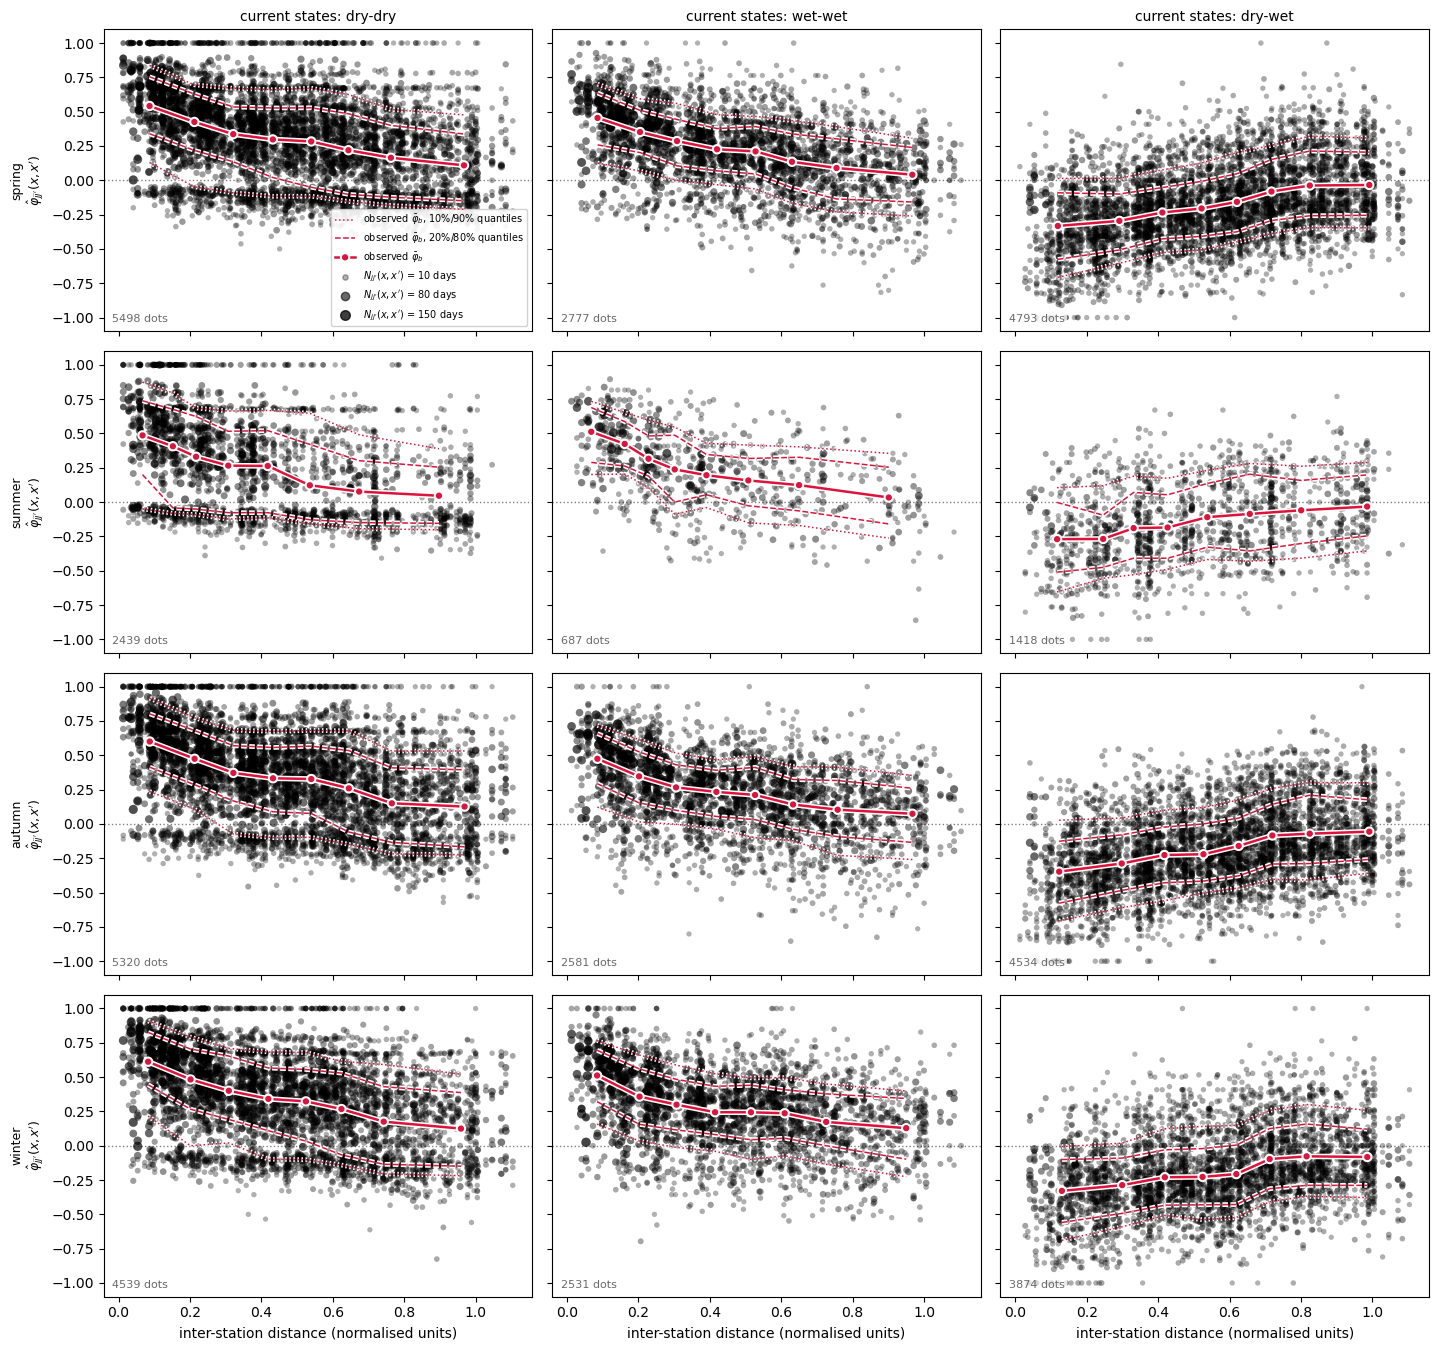

In [3]:
plot_phi_per_cell_season_grid(
    cells_by_season, seasons=SEASONS, legend_ns=(10, 80, 150),
    filenames=figure_targets("diag_switch_phi_duration_per_cell_seasons"),
)

summary = season_trend_summary(cells_by_season, seasons=SEASONS)
summary.to_csv(OUTPUT_DIR / "switch_phi_duration_season_summary.csv", index=False)
print(summary.round(3).to_string(index=False))
print(f"\ntotal dots over the grid: {summary['n_dots'].sum()}, "
      f"largest N = {summary['max_N'].max()}");

## Figure 2 — observed and simulated clouds, one sub-row each

The dot cloud above *motivated* the LMC; the closing check is that the fitted model reproduces it. Per season, `simulate_phi_cells` draws `N_REP` stationary trajectories from $\hat\theta$ ([spatial_lin_mod_coregion_fit_spain_portugal.ipynb](spatial_lin_mod_coregion_fit_spain_portugal.ipynb), state-dependent model) with the algorithm of §"Simulation from a fitted model", each of the length of the observed record, then

1. blanks the days the corresponding station does not record (observed NaN pattern) and rebuilds $(R, D, S)$ with the *same* `history_from_Rbin_drop_ambiguous_spell_after_nan`, so durations restart on gaps and season boundaries exactly as in the observations;
2. pushes the result through the *same* `switch_phi_duration_cells`.

The simulated estimates therefore sit in the same cells, with the same $N$'s and the same admissibility filter, as the observed ones: the two clouds carry the same estimation noise. Each season then gets a block of two sub-rows on shared axes — observed on top (black dots, red curve), the simulated replicate `REP_SHOWN` below (blue dots, blue curve) — so neither cloud hides the other. The curve is the $N$-weighted **median** of the dots of the panel in each of the eight equal-count distance bins.

`N_REP` replicates $\times$ 4 seasons, a few seconds each — nothing is cached here, so lower `N_REP` for a quick pass.

[spring] theta_hat: lam0=0.847, lam1=0.199, sigma_wc=0.743, sigma_w0=0.015, sigma_w1=0.273


         10 replicates, 9462 admissible estimates on average (observed: 13068)
[summer] theta_hat: lam0=0.873, lam1=0.245, sigma_wc=0.440, sigma_w0=0.013, sigma_w1=0.240


         10 replicates, 3438 admissible estimates on average (observed: 4544)
[autumn] theta_hat: lam0=0.821, lam1=0.207, sigma_wc=0.861, sigma_w0=0.150, sigma_w1=0.290


         10 replicates, 9790 admissible estimates on average (observed: 12435)
[winter] theta_hat: lam0=0.349, lam1=0.476, sigma_wc=1.082, sigma_w0=0.509, sigma_w1=0.167


         10 replicates, 8455 admissible estimates on average (observed: 10944)


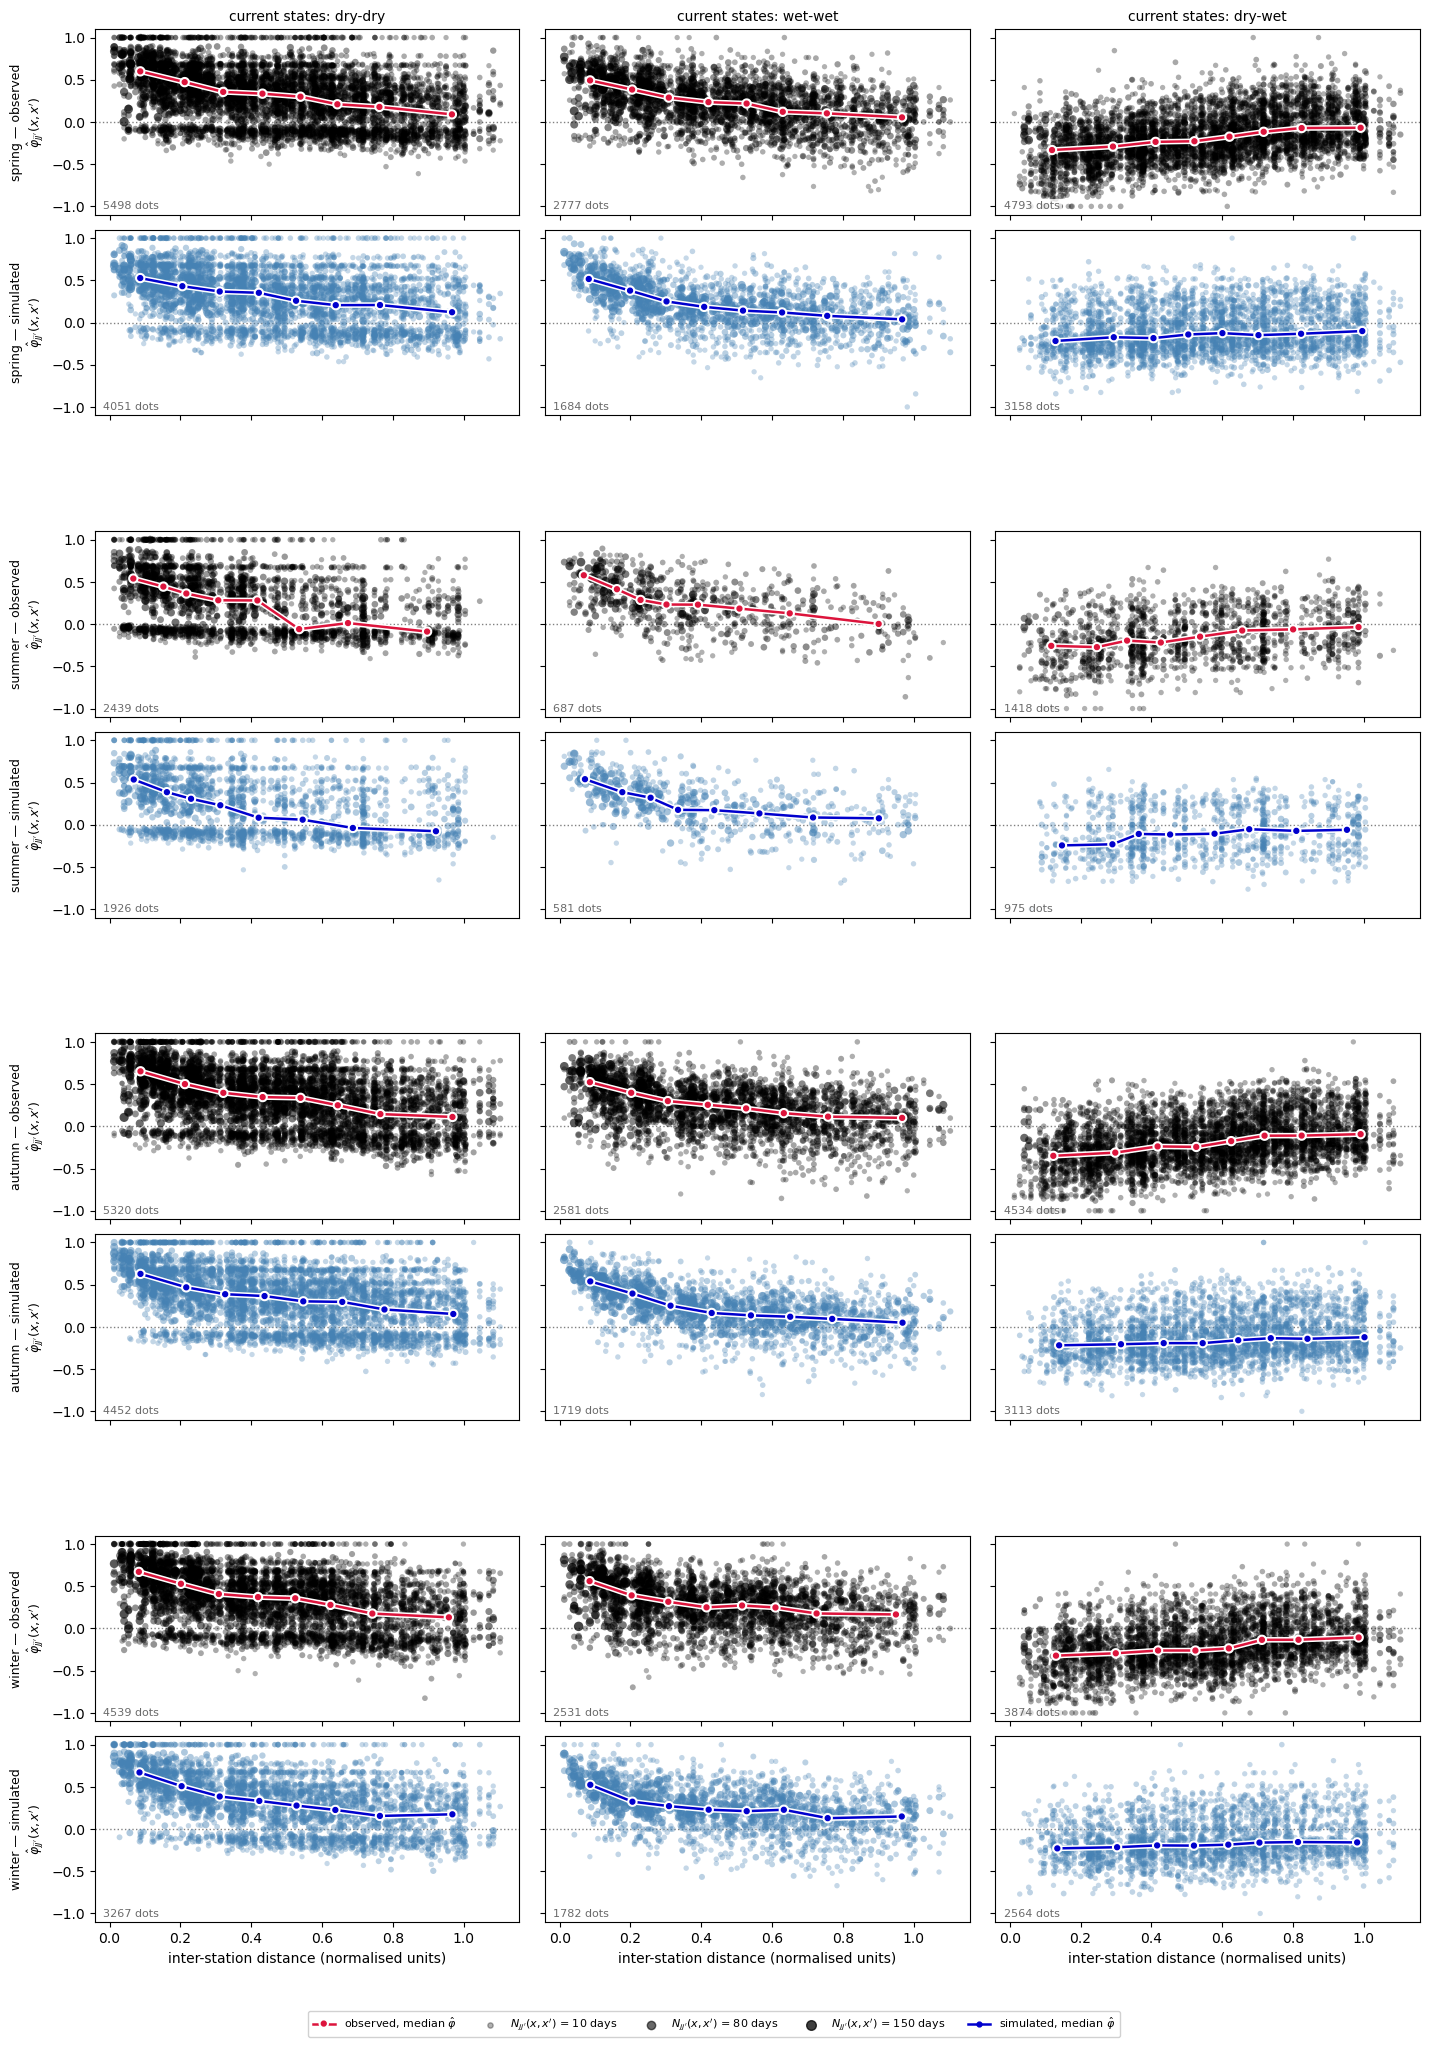

In [4]:
N_REP = 10
REP_SHOWN = 0
THETA_KEYS = ["lam0", "lam1", "sigma_wc", "sigma_w0", "sigma_w1"]
theta_csv = OUTPUT_DIR / "theta_fit_spain_portugal_by_season_state_dep_lambda.csv"

theta_by_season, sim_cells_by_season = {}, {}
if theta_csv.exists():
    df_theta = pd.read_csv(theta_csv, index_col="season")
    for season in SEASONS:
        theta = tuple(df_theta.loc[season, k] for k in THETA_KEYS)
        theta_by_season[season] = theta
        print(f"[{season:>6}] theta_hat: "
              + ", ".join(f"{k}={v:.3f}" for k, v in zip(THETA_KEYS, theta)))
        sim_cells_by_season[season] = simulate_phi_cells(
            theta, params_by_station_by_season[season], Rbin_by_season[season],
            n_rep=N_REP, min_days_per_cell=MIN_DAYS, seed0=100, verbose=False,
        )
        n_adm = np.mean([np.isfinite(df["phi"]).sum() for df in sim_cells_by_season[season]])
        n_obs = int(np.isfinite(cells_by_season[season]["phi"]).sum())
        print(f"         {N_REP} replicates, {n_adm:.0f} admissible estimates on average "
              f"(observed: {n_obs})")

    plot_phi_obs_vs_sim_paired_rows(
        cells_by_season, sim_cells_by_season, seasons=SEASONS,
        rep_index=REP_SHOWN, legend_ns=(10, 80, 150),
        filenames=figure_targets("diag_switch_phi_duration_per_cell_seasons_obs_vs_sim"),
    );
else:
    print(f"{theta_csv.name} not found -- run the fit notebook first; comparison skipped")

## Figure 3 — the two distributions of $\widehat{\psi}$, curves only

Same comparison as Figure 2 but both estimations on the same axes and without the dots: per distance bin, the $N$-weighted median (solid, markers) and the top **and** bottom 10%, 20%, 30%, 40% levels — the weighted 10/90, 20/80, 30/70 and 40/60 quantile pairs of the dots of that bin, the two curves of a pair sharing a line style and one legend entry — in red for the observations and blue for the simulated replicates (pooled, `N_REP` $\times$ the observed record length). The medians compare the *level* of the exit dependence, the four nested pairs the *spread* of the per-state-pair estimates around it. (Other levels: pass `pairs=` / `singles=` to `plot_phi_quantile_fan_season_grid`, e.g. `pairs=(), singles=_TOP_QUANTILES` for the upper side only.)

N-weighted median (and 10%/90% levels), nearest and farthest distance bin:
season   class  obs_near  obs_far  obs_near_bot10  obs_near_top10  sim_near  sim_far  sim_near_bot10  sim_near_top10 bins_inside_replicate_band
spring dry-dry     0.600    0.090           0.130           0.837     0.524    0.117           0.218           0.775                        4/8
spring wet-wet     0.492    0.055           0.126           0.701     0.526    0.046           0.315           0.730                        4/8
spring dry-wet    -0.332   -0.069          -0.707           0.014    -0.218   -0.102          -0.447           0.178                        2/8
summer dry-dry     0.540   -0.088          -0.049           0.874     0.531   -0.077          -0.048           0.882                        6/8
summer wet-wet     0.579    0.003           0.201           0.735     0.529    0.029           0.345           0.761                        5/8
summer dry-wet    -0.257   -0.034          -0.655           0

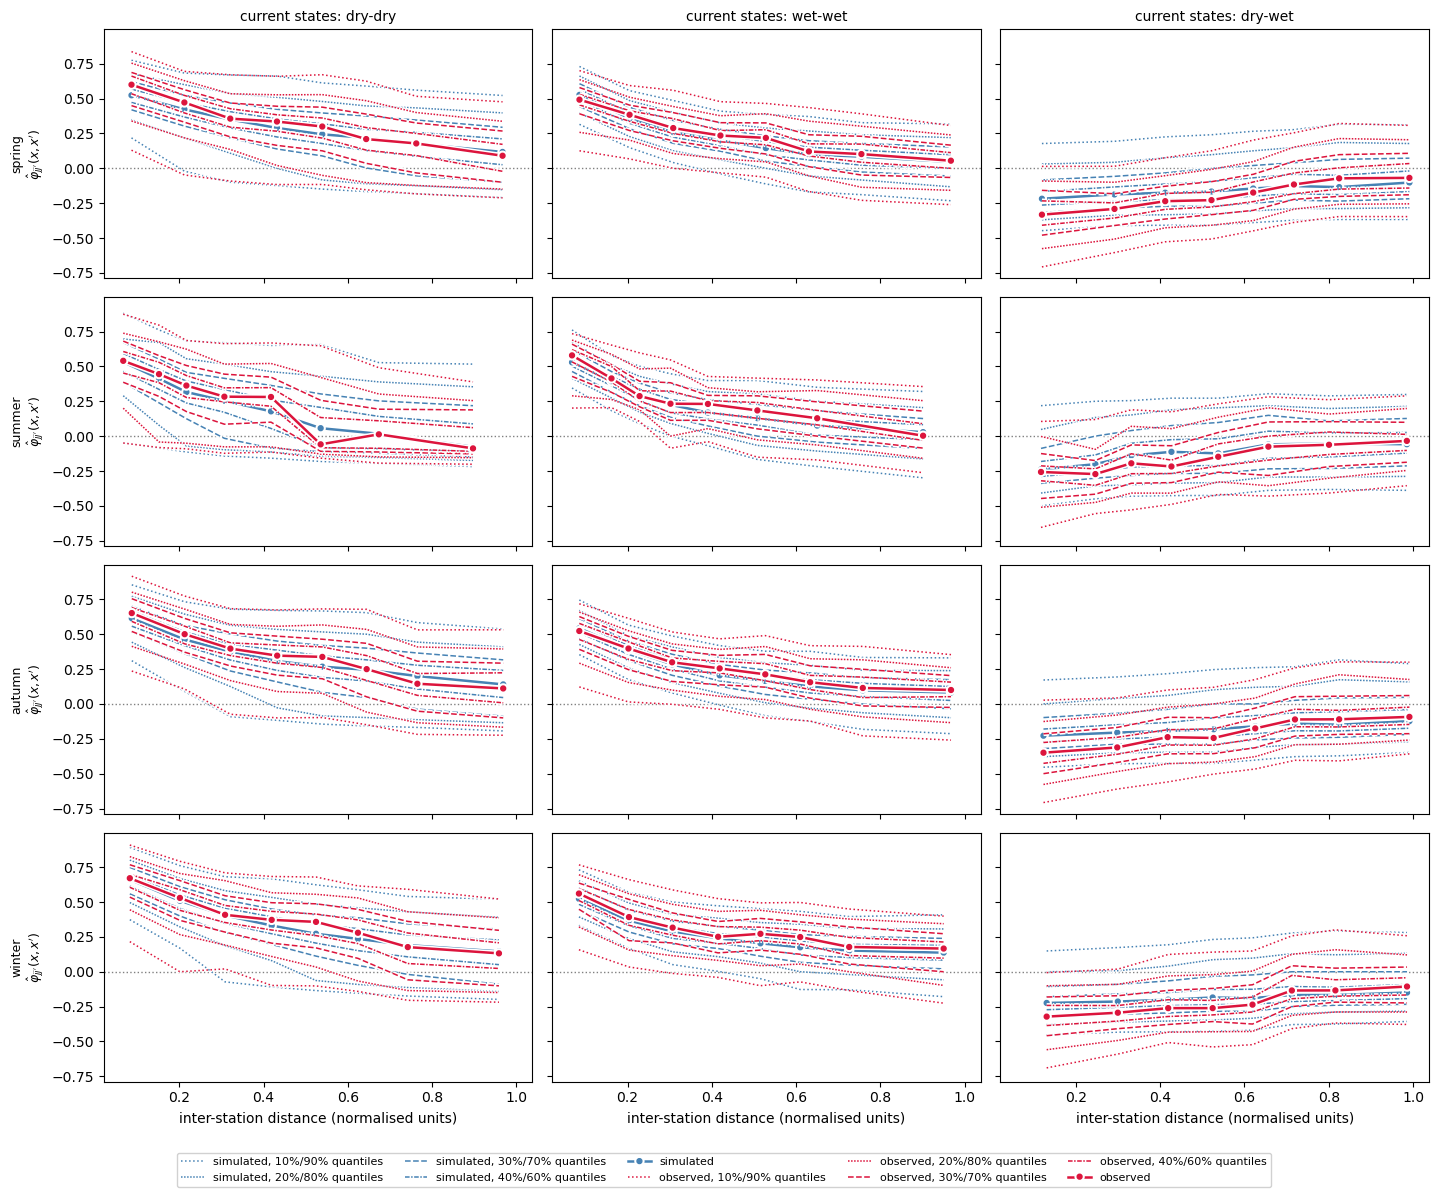

In [5]:
if sim_cells_by_season:
    plot_phi_quantile_fan_season_grid(
        cells_by_season, sim_cells_by_season, seasons=SEASONS,
        filenames=figure_targets("diag_switch_phi_duration_per_cell_seasons_quantile_fan"),
    )

    cmp_summary = obs_vs_sim_trend_summary(cells_by_season, sim_cells_by_season, seasons=SEASONS)
    cmp_summary.to_csv(OUTPUT_DIR / "switch_phi_duration_obs_vs_sim_summary.csv", index=False)
    print("N-weighted median (and 10%/90% levels), nearest and farthest distance bin:")
    print(cmp_summary.round(3).to_string(index=False));
else:
    print("no simulated replicates available -- run the previous cell first")

In [3]:
import sys, pathlib

_HERE = pathlib.Path.cwd().resolve()
_REPO_ROOT = next(
    (p for p in (_HERE, *_HERE.parents) if (p / "article_code").is_dir()),
    None,
)
if _REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root containing 'article_code/' from {_HERE}")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import json
import numpy as np
import pandas as pd

from article_code.util_files import config
from spatial_bmcd.spatial_model import (
    build_dict_model_params,
    filter_stations_by_nan_fraction,
    load_all_station_rr,
    prepare_station_fit_table,
)
from spatial_bmcd.switch_phi_duration_diagnostic import (
    compute_cells_from_raw,
    equal_duration_coverage,
    equal_duration_estimates,
    figure_targets,
    plot_psi_equal_duration_grid,
    plot_psi_equal_duration_interactive,
    plot_zero_joint_exit_diagnostic,
)

SEASONS = list(config.SEASONS)
COUNTRIES = ["PT", "ES"]
YEAR_MIN, YEAR_MAX = 1980, 2020
D_MAX = 20      # equal durations d = d' = 1 ... D_MAX
MIN_DAYS = 10   # admissibility rule of the article

OUTPUT_DIR = _REPO_ROOT / "spatial_bmcd" / "experiment_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Single-site fitted spell distributions: only used by the raw-record fallback below.
base_filename = (
    f"ecad_data_south_europe_filtered_after_{config.START_YEAR}"
    f"_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json"
)
with open(config.EXPORTS_JSON_DIR / base_filename) as fh:
    spells = json.load(fh)
stations_metadata = pd.read_csv(config.STATION_METADATA_CSV)
stations_used = stations_metadata[stations_metadata["city"].isin(spells.keys())]

fit_folder = (
    config.RESULTS_FIT_DIR
    / f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}"
)
df_fit_dry = pd.read_csv(fit_folder / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv")
df_fit_wet = pd.read_csv(fit_folder / "wet_spell_fit_mixt_geomresult_fit_parameters.csv")
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s: s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s: s.split()[-1])

def build_params_by_season(stations_used):
    """Per-season {city: model parameters} of the PT/ES subset of `stations_used`."""
    out = {}
    for season in SEASONS:
        df_fit_dry_sub, df_fit_wet_sub = prepare_station_fit_table(
            df_fit_dry, df_fit_wet, stations_used, countries=COUNTRIES, season=season,
        )
        out[season] = build_dict_model_params(
            df_fit_dry_sub, df_fit_wet_sub, spells, season=season, show_progress=False,
        )
    return out

# Station set, settled in two passes: how incomplete a station is can only be
# read from the raw record, so a provisional set says which files to load,
# filter_stations_by_nan_fraction drops the stations missing more than
# MAX_NAN_FRACTION_STATION of the window (see spatial_bmcd/config_spatial.py),
# and the second pass is the definitive set. Only the load touches the disk.
params_by_season = build_params_by_season(stations_used)
stations_union = sorted(set().union(*(p.keys() for p in params_by_season.values())))
dfs_by_city = load_all_station_rr(
    config.ECAD_RAW_DIR, stations_to_get=stations_union, verbose=False,
)
stations_used = filter_stations_by_nan_fraction(stations_used, dfs_by_city)
params_by_season = build_params_by_season(stations_used)

print("stations per season: " + ", ".join(
    f"{s}={len(params_by_season[s])}" for s in SEASONS))

stations per season: spring=35, summer=35, autumn=35, winter=35


In [4]:
import numpy as np
import pandas as pd

# The sqrt(N) dot-area/opacity law of the article (Figure 1), reused so a dot's
# weight is read the same way here and in the psi figures above.
from switch_phi_duration_diagnostic import _sqrtn_size_alpha


def equal_duration_no_exit(cells: pd.DataFrame, d_max: int = 20) -> pd.DataFrame:
    """Diagonal d = d' <= ``d_max`` of a cell table, with the joint no-exit frequency.

    Same slice as ``equal_duration_estimates`` -- one row per (station pair,
    state pair) carrying the same duration at the two stations -- but keeping
    *every* such cell with n_days > 0, since

        p00_hat = (N - e_j - e_j' + e_jj') / N

    needs no non-degenerate margin. The cells eq. (9) has to drop (e_j or e_j'
    in {0, N}) are exactly the ones where one station never exits or always
    does, and they are informative here.

    Adds ``d`` (the common duration), ``n_no_exit`` (the joint no-exit count)
    and ``p00``. ``psi`` is also recomputed as in ``equal_duration_estimates``,
    left NaN where its denominator vanishes, so the hover can show it where it
    exists.
    """
    sub = cells[(cells["d_j"] == cells["d_k"]) & cells["d_j"].between(1, d_max)].copy()
    sub = sub[sub["n_days"] > 0]
    n = sub["n_days"].to_numpy(float)
    e_j, e_k = sub["n_exit_j"].to_numpy(float), sub["n_exit_k"].to_numpy(float)
    e_jk = sub["n_joint"].to_numpy(float)
    n00 = n - e_j - e_k + e_jk          # inclusion-exclusion on {b_j = 1} U {b_k = 1}
    var = e_j * (n - e_j) * e_k * (n - e_k)
    with np.errstate(invalid="ignore", divide="ignore"):
        psi = np.where(var > 0, (n * e_jk - e_j * e_k) / np.sqrt(var), np.nan)
    sub["d"] = sub["d_j"].astype(int)
    sub["n_no_exit"] = n00.astype(int)
    sub["p00"] = n00 / n
    sub["psi"] = psi
    return sub.reset_index(drop=True)


def no_exit_coverage(p00_by_season, d_max=20, state_class="dry-dry"):
    """Coverage of the p00 estimates of one state class.

    Returns ``(by_season, by_duration)``: the number of cells, their median and
    largest N and the share saturated at p00 = 1, per season; then one row per
    duration and one column per season holding ``"<cells> | <median N>"``, which
    is what tells the level of a dot apart from the noise of a three-day cell.
    """
    rows, per_d = [], {}
    index = range(1, d_max + 1)
    for season, diag in p00_by_season.items():
        sub = diag[(diag["state_class"] == state_class) & diag["d"].between(1, d_max)]
        rows.append({
            "season": season, "class": state_class, "dots": len(sub),
            "median N": sub["n_days"].median(), "max N": sub["n_days"].max(),
            "share p00 = 1": float(np.mean(sub["p00"] > 0.999)),
        })
        g = sub.groupby("d")
        counts = g.size().reindex(index).fillna(0).astype(int)
        med = g["n_days"].median().reindex(index).fillna(0).round(0).astype(int)
        per_d[season] = counts.astype(str) + " | " + med.astype(str)
    return pd.DataFrame(rows).set_index(["season", "class"]), pd.DataFrame(per_d)


#: Hover columns, in ``customdata`` order.
_NO_EXIT_HOVER_COLS = [
    "station_j", "station_k", "d", "n_days", "n_no_exit",
    "n_exit_j", "n_exit_k", "n_joint", "psi",
]


def plot_p00_equal_duration_interactive(
    p00_by_season,
    state_class: str = "dry-dry",
    min_n=None,
    d_max: int = 20,
    seasons=SEASONS,
    n_ref=None,
    n_cols: int = 1,
    height: int = 1250,
    cmap: str = "Viridis",
):
    """Hover-inspectable p00 against inter-station distance, one class at a time.

    The layout, the colour law and the sqrt(N) size/opacity law of
    ``plot_psi_equal_duration_grid``, with eq. (9) replaced by the joint no-exit
    frequency ``p00``: one row per season (``n_cols=2`` folds them into a 2x2
    grid instead), the dot colour carrying the common duration d = d' on the
    same logarithmic 1..d_max scale and the same colorbar as the psi figures.

    ``min_n=None`` -- the default -- draws every cell of the diagonal; pass
    ``min_n=10`` for the admissibility rule of the article, or any other
    threshold. With no filter the sqrt(N) law is the only cue separating a p00
    built on three days from one built on two hundred, so ``n_ref`` is taken
    from the *unfiltered* selection (the sizes do not rescale when a threshold
    is put back) and hovering a dot gives the counts behind it: N, the joint
    no-exit count, e_j, e_j', e_jj', and eq. (9) on the same cell where it is
    defined.

    No trend curve and no baseline line: p00 has no fixed independence value --
    it is (1 - q_j)(1 - q_j'), which varies from cell to cell -- so neither
    would mean anything. Returns the plotly figure; call ``.show()`` on it.
    """
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    seasons = list(seasons)
    frames, n_max = {}, 1.0
    for season in seasons:
        df = p00_by_season[season]
        df = df[(df["state_class"] == state_class) & df["d"].between(1, d_max)
                & np.isfinite(df["p00"])]
        if len(df):
            n_max = max(n_max, float(df["n_days"].max()))
        if min_n is not None:
            df = df[df["n_days"] >= min_n]
        frames[season] = df.sort_values("n_days", ascending=False)  # small dots last
    n_ref = n_max if n_ref is None else float(n_ref)

    ticks = [t for t in (1, 2, 3, 4, 5, 6, 8, 10, 14, 20) if t <= d_max]
    hover = (
        "<b>%{customdata[0]} &mdash; %{customdata[1]}</b><br>"
        "distance = %{x:.3f} &nbsp; duration d = d' = %{customdata[2]}<br>"
        "<b>p00 = %{y:.3f}</b> &nbsp; (%{customdata[4]} / %{customdata[3]} days)<br>"
        "e_j = %{customdata[5]} &nbsp; e_j' = %{customdata[6]} &nbsp; "
        "e_jj' = %{customdata[7]}<br>"
        "psi = %{customdata[8]:.3f}"
        "<extra></extra>"
    )

    n_rows = int(np.ceil(len(seasons) / n_cols))
    fig = make_subplots(
        rows=n_rows, cols=n_cols, subplot_titles=seasons,
        shared_xaxes=True, shared_yaxes=True,
        horizontal_spacing=0.07, vertical_spacing=0.06,
    )
    for i, season in enumerate(seasons):
        row, col = i // n_cols + 1, i % n_cols + 1
        df = frames[season]
        # matplotlib's s is an area in pt^2, plotly's size a diameter in px.
        s_mpl, alpha = _sqrtn_size_alpha(df["n_days"].to_numpy(), n_ref)
        fig.add_trace(
            go.Scattergl(
                x=df["dist"], y=df["p00"], mode="markers",
                customdata=df[_NO_EXIT_HOVER_COLS].to_numpy(dtype=object),
                hovertemplate=hover, name=season, showlegend=False,
                marker=dict(
                    size=np.sqrt(s_mpl) * 2.2, opacity=alpha,
                    color=np.log10(df["d"].to_numpy(float)),
                    colorscale=cmap, cmin=np.log10(0.85), cmax=np.log10(d_max + 0.5),
                    line=dict(width=0),
                    colorbar=dict(
                        title=dict(text="d = d'", side="right"),
                        tickvals=np.log10(ticks), ticktext=[str(t) for t in ticks],
                        len=0.9, thickness=14,
                    ) if i == 0 else None,
                    showscale=(i == 0),
                ),
            ),
            row=row, col=col,
        )

    n_drawn = int(sum(len(df) for df in frames.values()))
    thr = "no filter on N" if min_n is None else f"N &ge; {min_n}"
    fig.update_xaxes(title_text="inter-station distance (normalised units)", row=n_rows)
    fig.update_yaxes(title_text="p00_hat", col=1, range=[-0.02, 1.02])
    fig.update_layout(
        height=height, hovermode="closest",
        title=dict(x=0.5, text=(
            f"P(B_j = B_j' = 0 | d = d' &le; {d_max}), {state_class}, {thr}"
            f"<br><span style='font-size:0.8em'>{n_drawn} cells</span>")),
        margin=dict(l=70, r=90, t=110, b=60),
    )
    return fig

In [6]:
missing = [s for s in SEASONS
           if not (OUTPUT_DIR / f"switch_phi_duration_cells_{s}.csv").exists()]
if missing:
    print("no cache for " + ", ".join(missing) + " -- recomputing from the raw record...")
    recomputed = compute_cells_from_raw(
        params_by_season, seasons=missing, year_min=YEAR_MIN, year_max=YEAR_MAX,
        min_days_per_cell=MIN_DAYS,
    )
    for season, cells in recomputed.items():
        cells.to_csv(OUTPUT_DIR / f"switch_phi_duration_cells_{season}.csv", index=False)

cells_by_season = {}
for season in SEASONS:
    csv_path = OUTPUT_DIR / f"switch_phi_duration_cells_{season}.csv"
    cells_by_season[season] = pd.read_csv(csv_path)
    print(f"[{season:>6}] {len(cells_by_season[season]):>7} cells  <- {csv_path.name}")

# The four rows of every figure must rest on the same stations to be comparable.
station_sets = {s: set(c["station_j"]).union(c["station_k"])
                for s, c in cells_by_season.items()}
common = set.intersection(*station_sets.values())
assert all(v == common for v in station_sets.values()), "seasonal station sets differ"
print(f"\n{len(common)} stations common to the four seasons, "
      f"{len(common) * (len(common) - 1) // 2} station pairs")

p00_by_season = {s: equal_duration_no_exit(c, d_max=D_MAX)
                 for s, c in cells_by_season.items()}

# Same counts as eq. (9): a frequency, and the psi recomputed here must match
# the one already carried by the psi diagonal wherever both are defined.
for season, diag in p00_by_season.items():
    assert diag["p00"].between(0.0, 1.0).all(), season
    n_psi = int(np.isfinite(diag["psi"]).sum())
    print(f"[{season:>6}] {len(diag):>6} cells on the diagonal d = d' <= {D_MAX} "
          f"({n_psi} carry a psi, {len(diag) - n_psi} have a degenerate margin)")

by_season_p00, by_duration_p00 = no_exit_coverage(
    p00_by_season, d_max=D_MAX, state_class="dry-dry",
)
print("\ndry-dry p00 estimates per season:")
print(by_season_p00.round(3).to_string())
print("\nper duration (cells | median N):")
print(by_duration_p00.to_string())

[spring]  200765 cells  <- switch_phi_duration_cells_spring.csv
[summer]  286640 cells  <- switch_phi_duration_cells_summer.csv
[autumn]  193686 cells  <- switch_phi_duration_cells_autumn.csv
[winter]  214685 cells  <- switch_phi_duration_cells_winter.csv

34 stations common to the four seasons, 561 station pairs
[spring]  13859 cells on the diagonal d = d' <= 20 (6098 carry a psi, 7761 have a degenerate margin)
[summer]  11178 cells on the diagonal d = d' <= 20 (3001 carry a psi, 8177 have a degenerate margin)
[autumn]  13920 cells on the diagonal d = d' <= 20 (6035 carry a psi, 7885 have a degenerate margin)
[winter]  14246 cells on the diagonal d = d' <= 20 (5843 carry a psi, 8403 have a degenerate margin)

dry-dry p00 estimates per season:
                dots  median N  max N  share p00 = 1
season class                                        
spring dry-dry  7402       4.0    174          0.413
summer dry-dry  7438       3.0    138          0.572
autumn dry-dry  7666       4.0    

In [9]:
p00_by_season["spring"]

,station_j,station_k,dist,state_class,r_j,r_k,d_j,d_k,n_days,n_exit_j,n_exit_k,n_joint,phi,d,n_no_exit,p00,psi
0,ALACANT/ALICANTE,ALMEIDINHA,0.653839,dry-dry,0,0,1,1,28,3,9,0,-0.238416,1,16,0.571429,-0.238416
1,ALACANT/ALICANTE,ALMEIDINHA,0.653839,dry-dry,0,0,2,2,15,2,4,1,0.206959,2,10,0.666667,0.206959
2,ALACANT/ALICANTE,ALMEIDINHA,0.653839,dry-dry,0,0,3,3,9,1,2,0,NaN,3,6,0.666667,-0.188982
3,ALACANT/ALICANTE,ALMEIDINHA,0.653839,dry-dry,0,0,4,4,5,0,1,0,NaN,4,4,0.800000,NaN
4,ALACANT/ALICANTE,ALMEIDINHA,0.653839,dry-dry,0,0,5,5,4,1,1,0,NaN,5,2,0.500000,-0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13854,VIMIANZO,ZAMORA,0.357294,wet-wet,1,1,5,5,4,0,2,0,NaN,5,2,0.500000,NaN
13855,VIMIANZO,ZAMORA,0.357294,wet-wet,1,1,6,6,2,0,1,0,NaN,6,1,0.500000,NaN
13856,VIMIANZO,ZAMORA,0.357294,wet-wet,1,1,7,7,1,0,0,0,NaN,7,1,1.000000,NaN
13857,VIMIANZO,ZAMORA,0.357294,wet-wet,1,1,8,8,1,0,0,0,NaN,8,1,1.000000,NaN


In [ ]:
p00_by_season['spring'][]

,station_j,station_k,dist,state_class,r_j,r_k,d_j,d_k,n_days,n_exit_j,n_exit_k,n_joint,phi,d,n_no_exit,p00,psi
0,ALACANT/ALICANTE,ALMEIDINHA,0.653839,dry-dry,0,0,1,1,8,0,3,0,NaN,1,5,0.625000,NaN
1,ALACANT/ALICANTE,ALMEIDINHA,0.653839,dry-dry,0,0,2,2,3,0,1,0,NaN,2,2,0.666667,NaN
2,ALACANT/ALICANTE,ALMEIDINHA,0.653839,dry-dry,0,0,3,3,2,0,1,0,NaN,3,1,0.500000,NaN
3,ALACANT/ALICANTE,ALMEIDINHA,0.653839,dry-dry,0,0,4,4,1,0,0,0,NaN,4,1,1.000000,NaN
4,ALACANT/ALICANTE,ALMEIDINHA,0.653839,dry-dry,0,0,5,5,1,0,0,0,NaN,5,1,1.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11173,VIMIANZO,ZAMORA,0.357294,dry-wet,1,0,5,5,2,1,0,0,NaN,5,1,0.500000,NaN
11174,VIMIANZO,ZAMORA,0.357294,dry-wet,1,0,6,6,1,0,0,0,NaN,6,1,1.000000,NaN
11175,VIMIANZO,ZAMORA,0.357294,wet-wet,1,1,1,1,25,8,14,5,0.089828,1,8,0.320000,0.089828
11176,VIMIANZO,ZAMORA,0.357294,wet-wet,1,1,2,2,8,5,4,3,NaN,2,2,0.250000,0.258199
